# Chapter 1 — Exploratory Data Analysis

**Book:** Practical Statistics for Data Scientists, 2nd Edition  
**Name:** Rainaldi Pakpahan  
**NIM:** 101032300084  
**Class:** TK 47-04  

## Tujuan

Chapter ini membahas Exploratory Data Analysis (EDA), yaitu proses
awal untuk memahami karakteristik data sebelum dilakukan analisis
yang lebih lanjut.

Pembahasan meliputi struktur data, statistik deskriptif, penyebaran,
distribusi, nilai ekstrem, data kategorikal, serta hubungan
antarvariabel.

## Alur Pembahasan

1. Persiapan library
2. Memuat dataset
3. Mengenali struktur data
4. Pemeriksaan kualitas data
5. Mengukur nilai pusat
6. Mengukur penyebaran
7. Menganalisis distribusi
8. Mendeteksi nilai ekstrem
9. Menganalisis data kategorikal
10. Melihat hubungan antarvariabel
11. Kesimpulan

In [1]:
%pip -q install wquantiles

In [2]:
from pathlib import Path
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wquantiles

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.3f}".format)

print("Library berhasil dimuat.")

Library berhasil dimuat.


### Interpretasi

Library yang diperlukan untuk melakukan analisis statistik dan
visualisasi telah berhasil dimuat. NumPy dan Pandas digunakan untuk
pengolahan data, sedangkan Matplotlib dan Seaborn digunakan untuk
visualisasi.

## 1. Memuat Dataset

Dataset digunakan sebagai contoh untuk menerapkan konsep
Exploratory Data Analysis. Sebelum melakukan analisis, data perlu
dimuat ke dalam lingkungan Python.

In [3]:
REPO_DIR = Path("/content/practical-statistics-for-data-scientists")
REPO_URL = "https://github.com/gedeck/practical-statistics-for-data-scientists.git"

if not REPO_DIR.exists():
    subprocess.run(
        ["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)],
        check=True
    )

DATA_DIR = REPO_DIR / "data"

print("Lokasi dataset:")
print(DATA_DIR)

Lokasi dataset:
/content/practical-statistics-for-data-scientists/data


In [4]:
state = pd.read_csv(DATA_DIR / "state.csv")

print("Jumlah baris :", state.shape[0])
print("Jumlah kolom :", state.shape[1])

state.head()

Jumlah baris : 50
Jumlah kolom : 4


,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.700,AL
1,Alaska,710231,5.600,AK
2,Arizona,6392017,4.700,AZ
3,Arkansas,2915918,5.600,AR
4,California,37253956,4.400,CA


### Interpretasi

Dataset berhasil dimuat ke dalam Pandas DataFrame. Baris pada dataset
merepresentasikan observasi, sedangkan kolom menunjukkan variabel yang
digunakan untuk analisis.

Pada tahap ini pemeriksaan masih bersifat umum sehingga belum dapat
digunakan untuk menarik kesimpulan statistik.

## 2. Mengenali Struktur Data

Sebelum menghitung statistik, setiap variabel perlu diperiksa untuk
mengetahui tipe datanya dan jumlah nilai yang tersedia.

In [5]:
overview = pd.DataFrame({
    "Tipe Data": state.dtypes.astype(str),
    "Jumlah Data": state.notna().sum(),
    "Missing Value": state.isna().sum()
})

overview

,Tipe Data,Jumlah Data,Missing Value
State,object,50,0
Population,int64,50,0
Murder.Rate,float64,50,0
Abbreviation,object,50,0


### Interpretasi

Hasil pemeriksaan menunjukkan tipe data pada setiap variabel serta
jumlah nilai yang tersedia. Variabel numerik dapat digunakan untuk
perhitungan statistik seperti mean, median, dan korelasi.

Pemeriksaan ini penting karena metode analisis harus disesuaikan
dengan jenis data yang digunakan.

## 3. Pemeriksaan Kualitas Data

Data perlu diperiksa sebelum dianalisis untuk mengetahui apakah
terdapat nilai kosong, data duplikat, atau nilai numerik yang tidak
valid.

In [6]:
numeric_data = state.select_dtypes(include=np.number)

audit = pd.Series({
    "Jumlah baris": len(state),
    "Jumlah kolom": state.shape[1],
    "Total missing value": int(state.isna().sum().sum()),
    "Baris duplikat": int(state.duplicated().sum()),
    "Nilai infinite": int(np.isinf(numeric_data).sum().sum())
})

audit

,0
Jumlah baris,50
Jumlah kolom,4
Total missing value,0
Baris duplikat,0
Nilai infinite,0



Berdasarkan hasil pemeriksaan, dataset terdiri dari 50 baris dan
4 kolom. Tidak ditemukan missing value, baris duplikat, maupun
nilai infinite pada dataset.

Hal ini menunjukkan bahwa kondisi awal dataset cukup bersih sehingga
dapat dilanjutkan ke tahap analisis berikutnya tanpa perlu melakukan
penanganan khusus terhadap ketiga masalah tersebut.

## 4. Statistik Deskriptif

Statistik deskriptif digunakan untuk mendapatkan gambaran awal
mengenai data. Ukuran yang digunakan meliputi mean, median,
minimum, maksimum, dan kuartil.

In [7]:
state.describe()

,Population,Murder.Rate
count,50.000,50.000
mean,"6,162,876.300",4.066
std,"6,848,235.347",1.916
min,"563,626.000",0.900
25%,"1,833,004.250",2.425
50%,"4,436,369.500",4.000
75%,"6,680,312.250",5.550
max,"37,253,956.000",10.300


### Interpretasi

Berdasarkan statistik deskriptif, dataset memiliki 50 observasi untuk
variabel Population dan Murder.Rate.

Variabel Population memiliki nilai rata-rata sebesar 6,162,876.3,
sedangkan mediannya sebesar 4,436,369.5. Nilai maksimum mencapai
37,253,956 dan jauh lebih tinggi dibandingkan median. Perbedaan ini
menunjukkan bahwa terdapat beberapa negara bagian dengan jumlah
penduduk yang sangat besar sehingga dapat menarik nilai rata-rata ke
atas.

Untuk variabel Murder.Rate, nilai rata-ratanya sebesar 4.066 dan
mediannya sebesar 4.000. Nilai minimum adalah 0.9, sedangkan nilai
maksimum mencapai 10.3. Perbedaan antara minimum dan maksimum
menunjukkan bahwa tingkat murder rate memiliki variasi antarnegara
bagian.

In [8]:
population = state["Population"]

mean_population = population.mean()
median_population = population.median()

print(f"Mean   : {mean_population:,.2f}")
print(f"Median : {median_population:,.2f}")

Mean   : 6,162,876.30
Median : 4,436,369.50


### Interpretasi

Mean menunjukkan rata-rata jumlah populasi pada observasi yang
digunakan, sedangkan median menunjukkan nilai tengah setelah data
diurutkan.

Perbandingan mean dan median dapat membantu melihat apakah distribusi
dipengaruhi oleh beberapa nilai yang sangat besar atau sangat kecil.

In [9]:
quantiles = population.quantile([0.25, 0.50, 0.75])

quantiles

,Population
0.250,"1,833,004.250"
0.500,"4,436,369.500"
0.750,"6,680,312.250"


### Interpretasi

Quantile digunakan untuk mengetahui posisi data dalam distribusi.
Nilai 25% menunjukkan batas seperempat bagian bawah data, sedangkan
75% menunjukkan batas tiga perempat bagian data.

Nilai 50% sama dengan median karena berada di tengah distribusi.

## 5. Ukuran Penyebaran

Ukuran pusat belum cukup untuk menggambarkan data. Kita juga perlu
mengetahui seberapa jauh nilai-nilai dalam dataset tersebar.

In [10]:
q1 = population.quantile(0.25)
q3 = population.quantile(0.75)

spread = pd.Series({
    "Range": population.max() - population.min(),
    "Variance": population.var(),
    "Standard Deviation": population.std(),
    "IQR": q3 - q1
})

spread

,0
Range,"36,690,330.000"
Variance,"46,898,327,373,394.445"
Standard Deviation,"6,848,235.347"
IQR,"4,847,308.000"


### Interpretasi

Berdasarkan hasil pengukuran penyebaran, nilai range pada variabel
Population adalah 36,690,330. Nilai tersebut menunjukkan jarak yang
sangat besar antara populasi terkecil dan terbesar dalam dataset.

Standard deviation sebesar 6,848,235.347 menunjukkan bahwa nilai
Population memiliki penyebaran yang cukup tinggi dari nilai rata-ratanya.
Hal ini sesuai dengan perbedaan yang besar antara mean dan median pada
analisis sebelumnya.

Nilai IQR sebesar 4,847,308 menunjukkan rentang tempat 50% data bagian
tengah berada, yaitu dari kuartil pertama hingga kuartil ketiga.
Dibandingkan dengan range, IQR lebih menggambarkan penyebaran bagian
utama data karena tidak terlalu dipengaruhi oleh nilai ekstrem.

Variance memiliki nilai yang sangat besar karena merupakan ukuran
penyebaran dalam bentuk kuadrat dari satuan data. Oleh karena itu,
standard deviation biasanya lebih mudah digunakan untuk memahami
besarnya penyebaran dalam satuan asli Population.

## 6. Distribusi Data

Distribusi data dapat diamati secara visual menggunakan histogram.
Histogram membantu melihat konsentrasi data dan bentuk distribusinya.

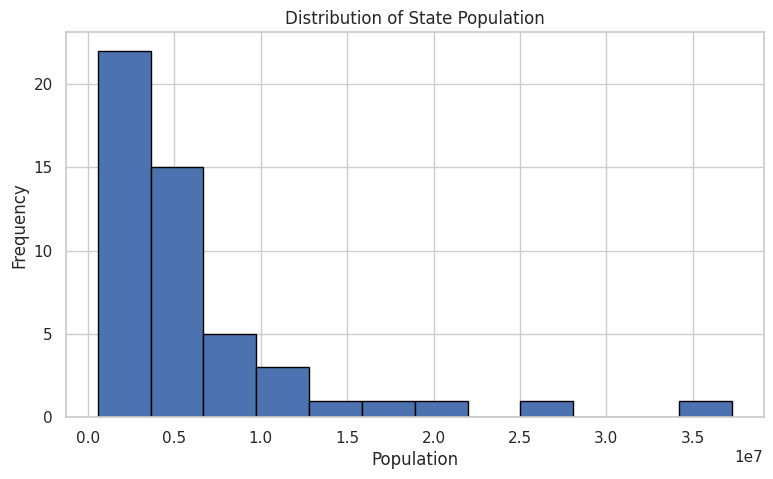

In [11]:
plt.figure(figsize=(9, 5))

plt.hist(
    population,
    bins=12,
    edgecolor="black"
)

plt.xlabel("Population")
plt.ylabel("Frequency")
plt.title("Distribution of State Population")

plt.show()

### Interpretasi

Histogram menunjukkan bahwa sebagian besar Population berada pada
nilai yang relatif rendah, sedangkan hanya beberapa data yang memiliki
populasi sangat tinggi. Distribusinya cenderung miring ke kanan karena
terdapat beberapa nilai ekstrem pada bagian kanan grafik.

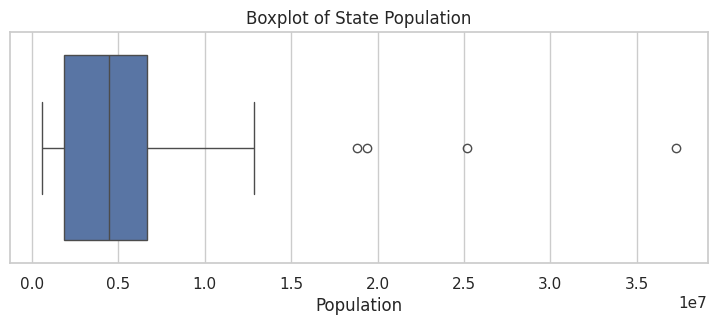

In [12]:
plt.figure(figsize=(9, 3))

sns.boxplot(x=population)

plt.xlabel("Population")
plt.title("Boxplot of State Population")

plt.show()

### Interpretasi

Boxplot menunjukkan sebagian besar data berada pada rentang sekitar
0–13 juta. Terdapat beberapa titik jauh di sebelah kanan yang
menunjukkan adanya nilai ekstrem (outlier).

## 7. Mendeteksi Nilai Ekstrem

Salah satu metode sederhana untuk mendeteksi kandidat outlier adalah
aturan Interquartile Range (IQR).

Batas bawah = Q1 - 1.5 × IQR

Batas atas = Q3 + 1.5 × IQR

In [13]:
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = state[
    (state["Population"] < lower_bound) |
    (state["Population"] > upper_bound)
]

print("Batas bawah :", lower_bound)
print("Batas atas  :", upper_bound)
print("Jumlah kandidat outlier :", len(outliers))

outliers[["State", "Population"]]

Batas bawah : -5437957.75
Batas atas  : 13951274.25
Jumlah kandidat outlier : 4


,State,Population
4,California,37253956
8,Florida,18801310
31,New York,19378102
42,Texas,25145561


### Interpretasi

Hasil IQR menunjukkan terdapat 4 kandidat outlier, yaitu California,
Florida, New York, dan Texas. Nilai populasi keempat negara bagian
tersebut berada di atas batas atas IQR.

## 8. Analisis Data Kategorikal

Selain variabel numerik, data kategorikal juga dapat dieksplorasi.
Untuk mempermudah perbandingan, populasi dibagi menjadi tiga kelompok:
rendah, sedang, dan tinggi.

In [14]:
state_analysis = state.copy()

state_analysis["Population_Group"] = pd.qcut(
    state_analysis["Population"],
    q=3,
    labels=["Rendah", "Sedang", "Tinggi"]
)

state_analysis["Population_Group"].value_counts().sort_index()

,count
Population_Group,
Rendah,17
Sedang,16
Tinggi,17


### Interpretasi

Data terbagi menjadi tiga kelompok populasi dengan jumlah yang hampir
seimbang, yaitu 17 pada kelompok rendah, 16 pada kelompok sedang, dan
17 pada kelompok tinggi.

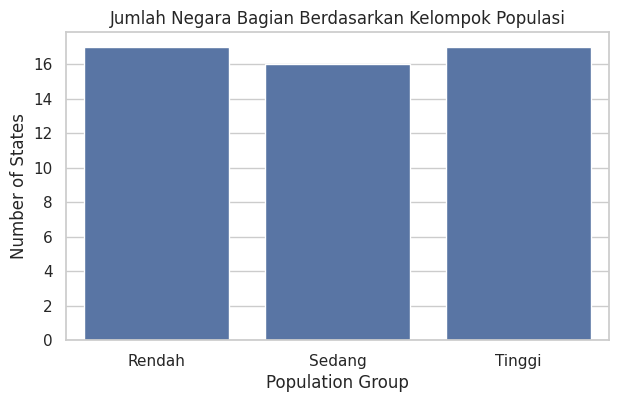

In [15]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=state_analysis,
    x="Population_Group"
)

plt.xlabel("Population Group")
plt.ylabel("Number of States")
plt.title("Jumlah Negara Bagian Berdasarkan Kelompok Populasi")

plt.show()

### Interpretasi

Grafik menunjukkan jumlah negara bagian pada ketiga kelompok populasi
relatif seimbang, dengan kelompok sedang memiliki jumlah sedikit lebih
rendah dibandingkan kelompok lainnya.

## 9. Hubungan Antarvariabel

Hubungan antarvariabel numerik dapat dianalisis menggunakan korelasi.
Korelasi digunakan untuk melihat arah dan kekuatan hubungan linear
antara dua variabel.

Nilai korelasi berada pada rentang -1 sampai 1.

In [16]:
corr = state[
    ["Population", "Murder.Rate"]
].corr()

corr

,Population,Murder.Rate
Population,1.000,0.182
Murder.Rate,0.182,1.000


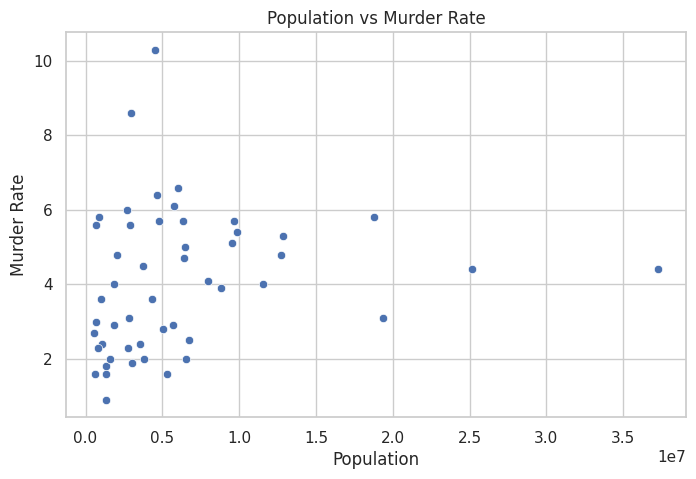

In [17]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=state,
    x="Population",
    y="Murder.Rate"
)

plt.xlabel("Population")
plt.ylabel("Murder Rate")
plt.title("Population vs Murder Rate")

plt.show()

### Interpretasi

Nilai korelasi sebesar 0.182 menunjukkan adanya hubungan positif yang
lemah antara Population dan Murder.Rate. Scatter plot juga menunjukkan
bahwa titik data cukup menyebar sehingga hubungan linear antara kedua
variabel tidak kuat.

## 10. Perbandingan Berdasarkan Kelompok

Setelah membuat kelompok populasi, kita dapat melihat apakah terdapat
perbedaan nilai rata-rata dan median murder rate pada setiap kelompok.

In [18]:
group_summary = (
    state_analysis
    .groupby(
        "Population_Group",
        observed=False
    )["Murder.Rate"]
    .agg(["count", "mean", "median"])
    .round(3)
)

group_summary

,count,mean,median
Population_Group,,,
Rendah,17,3.135,2.700
Sedang,16,4.631,4.050
Tinggi,17,4.465,4.700


### Interpretasi

Kelompok rendah memiliki mean murder rate sebesar 3.135, sedangkan
kelompok sedang dan tinggi masing-masing sebesar 4.631 dan 4.465.
Artinya, kelompok rendah memiliki rata-rata murder rate yang lebih
rendah dibandingkan dua kelompok lainnya.

## 11. Ringkasan Chapter 1

Beberapa teknik utama yang digunakan dalam Exploratory Data Analysis
adalah:

| Teknik | Fungsi |
|---|---|
| Mean | Menghitung nilai rata-rata |
| Median | Menentukan nilai tengah |
| Quantile | Melihat posisi data |
| Standard Deviation | Mengukur penyebaran |
| IQR | Mengukur rentang data bagian tengah |
| Histogram | Melihat bentuk distribusi |
| Boxplot | Melihat penyebaran dan outlier |
| Count Plot | Membandingkan kategori |
| Correlation | Mengukur hubungan linear |
| Scatter Plot | Melihat pola dua variabel |

## 12. Kesimpulan

Exploratory Data Analysis merupakan tahap penting untuk memahami
dataset sebelum dilakukan analisis statistik atau pemodelan.

Pada chapter ini dilakukan pemeriksaan struktur dan kualitas data,
perhitungan ukuran pusat dan penyebaran, analisis distribusi,
identifikasi kandidat outlier, pengelompokan data kategorikal,
serta analisis hubungan antarvariabel.

Dari proses tersebut dapat diketahui bahwa satu metode statistik
tidak selalu cukup untuk menjelaskan data. Statistik deskriptif perlu
dilengkapi dengan visualisasi agar pola dan karakteristik data dapat
dipahami dengan lebih baik.

Selain itu, nilai ekstrem tidak selalu merupakan kesalahan dan
korelasi tidak dapat langsung dianggap sebagai hubungan sebab-akibat.

## Referensi

Bruce, P., Bruce, A., & Gedeck, P. (2020).
*Practical Statistics for Data Scientists: 50+ Essential Concepts
Using R and Python*. 2nd Edition. O'Reilly Media.

Repository kode dan dataset:
https://github.com/gedeck/practical-statistics-for-data-scientists